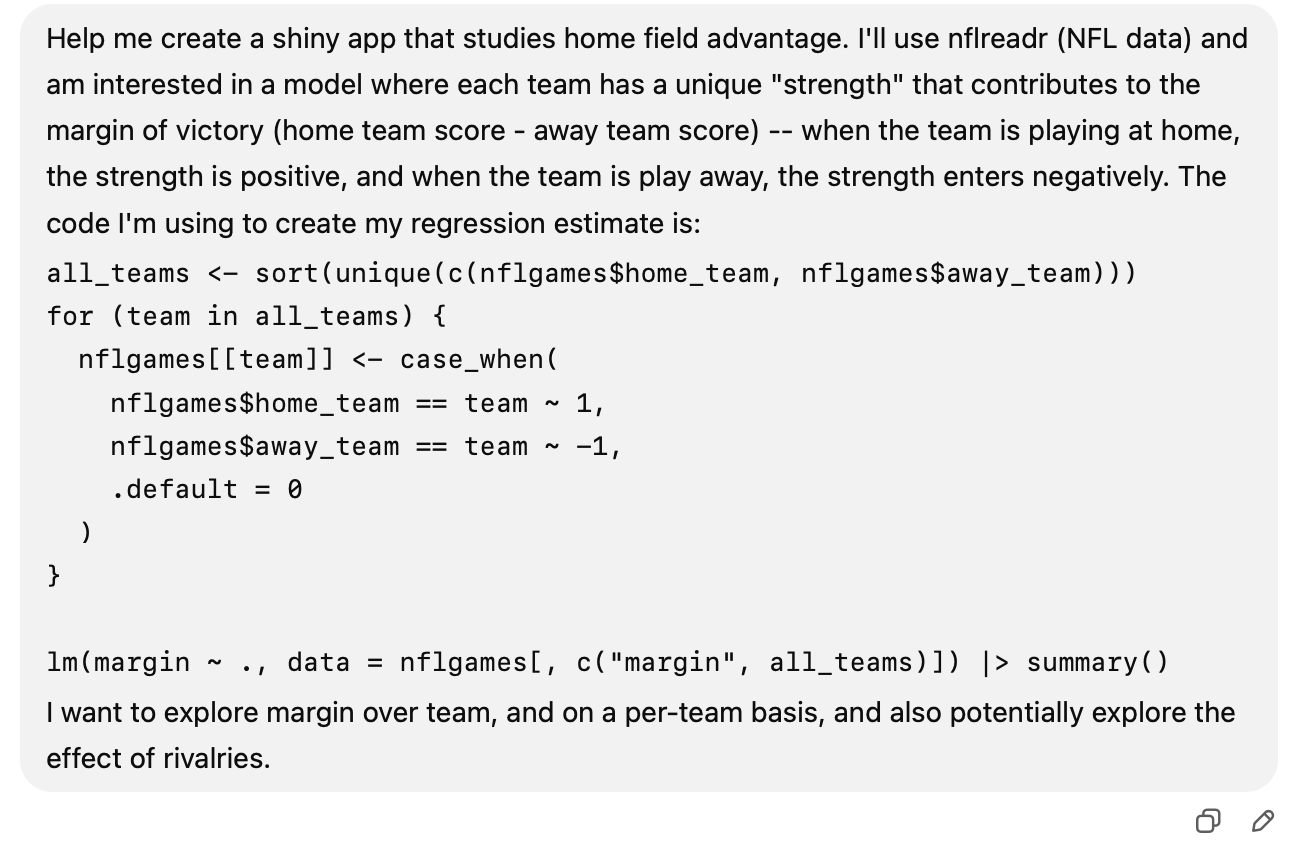

In [ ]:
library(shiny)
library(dplyr)
library(ggplot2)
library(nflreadr)
library(purrr)
library(stringr)

ui <- fluidPage(
  titlePanel("NFL Home Field Advantage Explorer"),

  sidebarLayout(
    sidebarPanel(
      h4("Controls"),
      selectInput("team", "Select Team:", choices = NULL),
      selectInput("rival_a", "Rivalry: Team A", choices = NULL),
      selectInput("rival_b", "Rivalry: Team B", choices = NULL),
      br(),
      helpText("Model: margin = Σ_j β_j * indicator_j + ε")
    ),

    mainPanel(
      tabsetPanel(
        tabPanel("Team Strength Estimates", plotOutput("coef_plot")),
        tabPanel("Margins by Team", plotOutput("team_margins")),
        tabPanel("Rivalries", plotOutput("rivalry_plot"))
      )
    )
  )
)

server <- function(input, output, session) {

  ####################################################################
  # 1. Load and prepare data
  ####################################################################

  games <- reactive({
    g <- nflreadr::load_schedules() |>
      filter(game_type == "REG", !is.na(home_score), !is.na(away_score)) |>
      mutate(
        margin = home_score - away_score,
        home_team = as.factor(home_team),
        away_team = as.factor(away_team)
      )

    teams <- sort(unique(c(g$home_team, g$away_team)))

    # Build design matrix
    for (team in teams) {
      g[[team]] <- case_when(
        g$home_team == team ~ 1,
        g$away_team == team ~ -1,
        .default = 0
      )
    }

    return(list(data = g, teams = teams))
  })

  observe({
    updateSelectInput(session, "team", choices = games()$teams)
    updateSelectInput(session, "rival_a", choices = games()$teams)
    updateSelectInput(session, "rival_b", choices = games()$teams)
  })

  ####################################################################
  # 2. Fit model
  ####################################################################

  model_fit <- reactive({
    g <- games()$data
    teams <- games()$teams
    lm(margin ~ ., data = g[, c("margin", teams)])
  })

  ####################################################################
  # 3. Team strength coefficient plot
  ####################################################################

  output$coef_plot <- renderPlot({
    fit <- model_fit()
    teams <- games()$teams
    coefs <- coef(fit)[teams]

    df <- tibble(team = teams, strength = coefs)

    ggplot(df, aes(x = reorder(team, strength), y = strength)) +
      geom_col() +
      coord_flip() +
      labs(title = "Estimated Team Strength Coefficients",
           x = "Team", y = "Strength (HFA-adjusted effect)") +
      theme_minimal()
  })

  ####################################################################
  # 4. Margins by team
  ####################################################################

  output$team_margins <- renderPlot({
    g <- games()$data
    req(input$team)

    df <- g |>
      filter(home_team == input$team | away_team == input$team) |>
      mutate(location = ifelse(home_team == input$team, "Home", "Away"))

    ggplot(df, aes(x = location, y = margin)) +
      geom_boxplot() +
      geom_jitter(alpha = 0.4, width = 0.2) +
      labs(title = paste("Margins for", input$team),
           y = "Home Score – Away Score", x = "Location") +
      theme_minimal()
  })

  ####################################################################
  # 5. Rivalry explorer
  ####################################################################

  output$rivalry_plot <- renderPlot({
    g <- games()$data
    req(input$rival_a, input$rival_b)

    df <- g |>
      filter(
        (home_team == input$rival_a & away_team == input$rival_b) |
        (home_team == input$rival_b & away_team == input$rival_a)
      ) |>
      mutate(matchup = paste(home_team, "vs", away_team))

    ggplot(df, aes(x = as.factor(season), y = margin, color = home_team)) +
      geom_hline(yintercept = 0, linetype = "dashed") +
      geom_point(size = 3) +
      labs(
        title = paste("Rivalry:", input$rival_a, "vs", input$rival_b),
        x = "Season", y = "Home – Away Margin"
      ) +
      theme_minimal()
  })

}

shinyApp(ui, server)

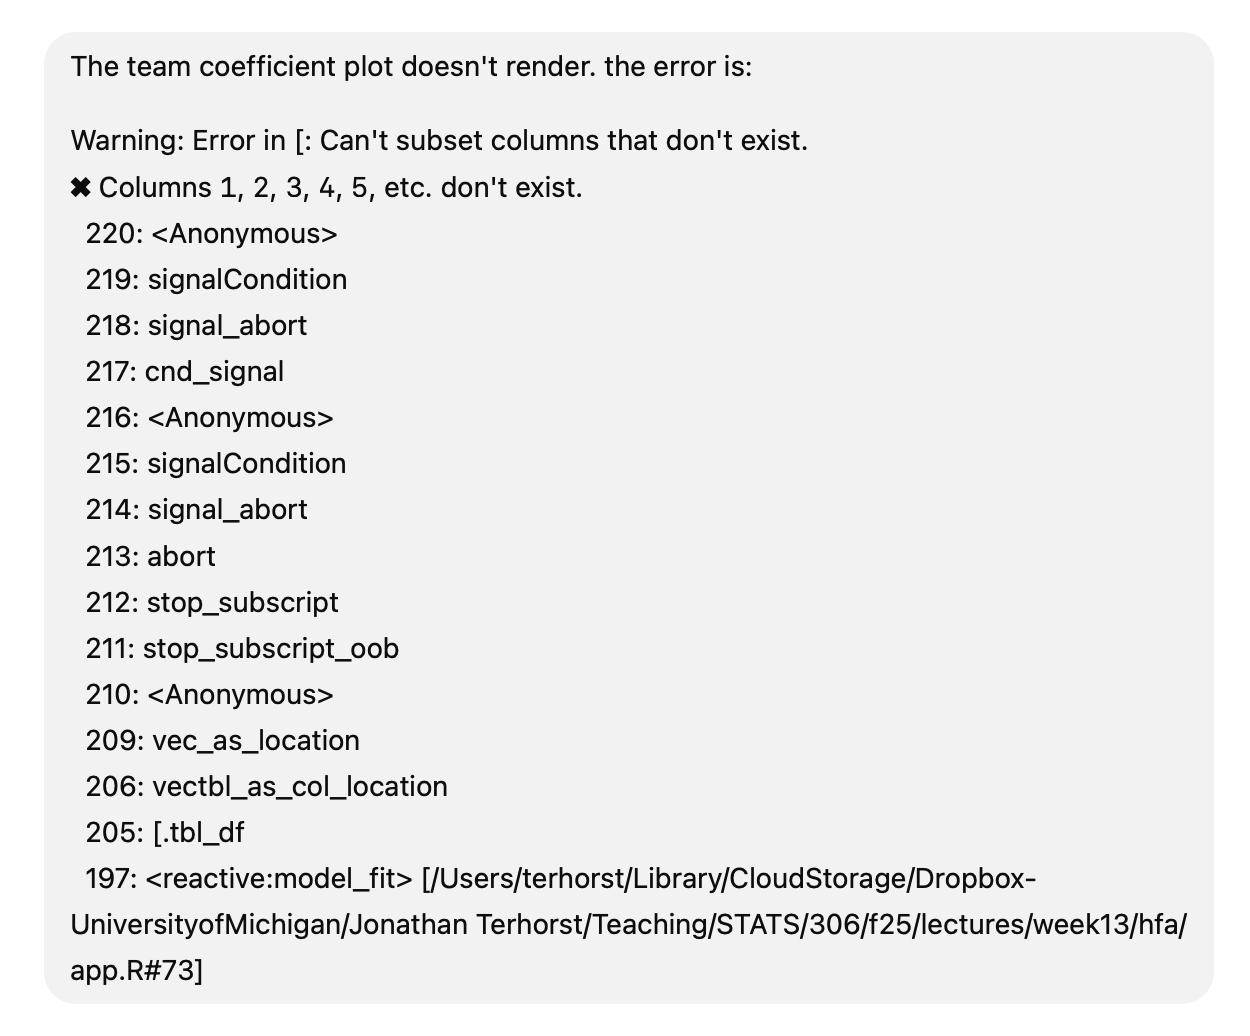

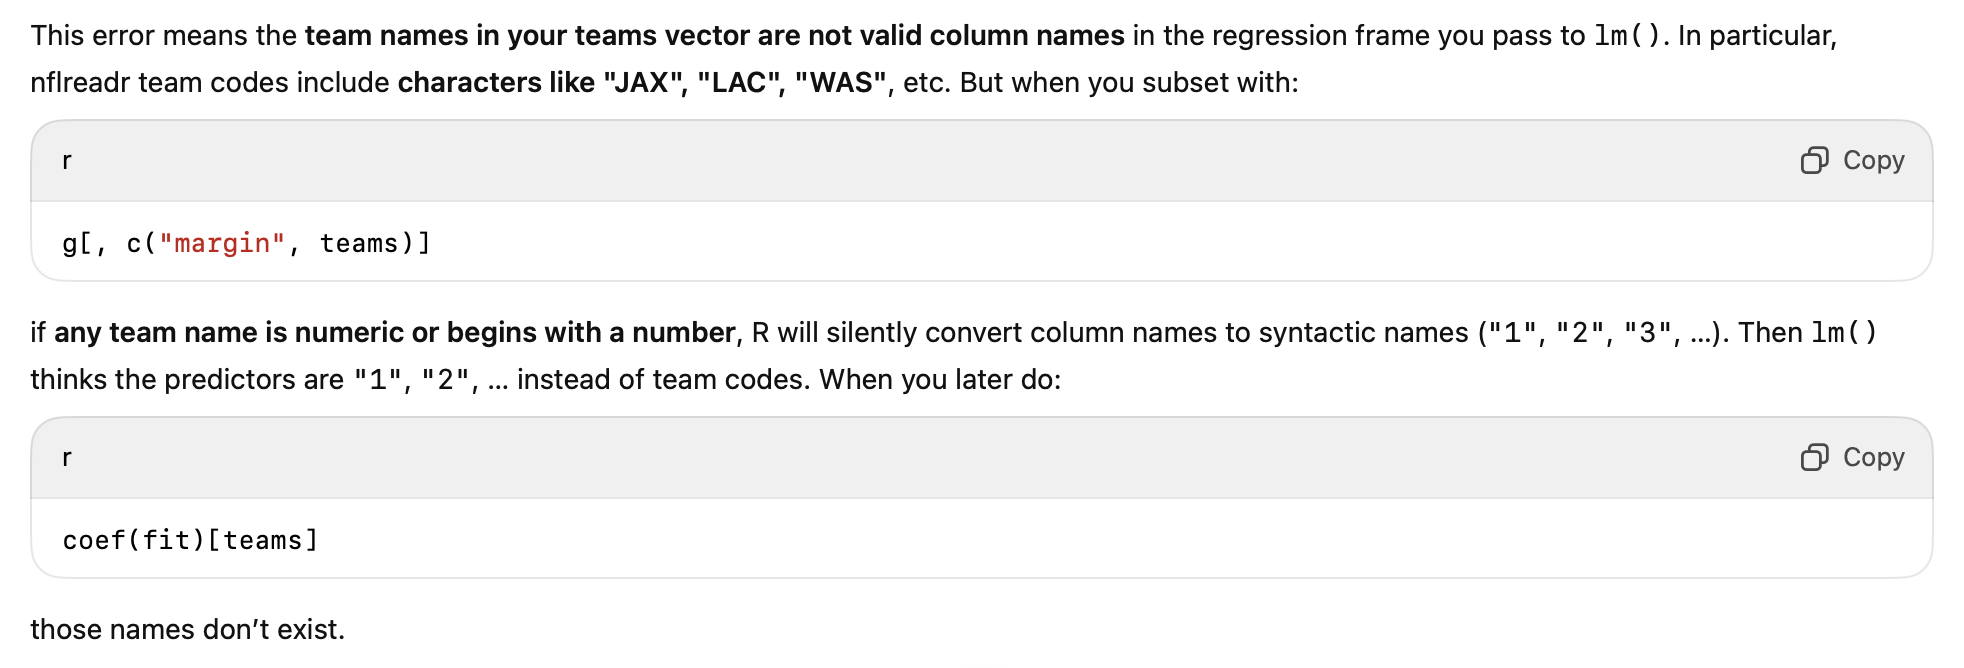

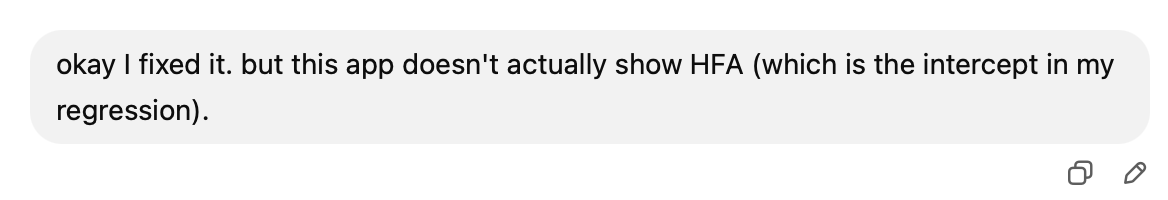

In [ ]:
# add to the ui
verbatimTextOutput("team_hfa_text")

# add to the server
output$team_hfa_text <- renderPrint({
  req(input$team)
  fit <- model_fit()
  hfa <- coef(fit)[1]
  beta <- coef(fit)[input$team]

  cat("Predicted margins for", input$team, "vs a league-average opponent:\n")
  cat(sprintf("  Home: %.2f\n",  hfa + beta))
  cat(sprintf("  Away: %.2f\n", -hfa + beta))
})

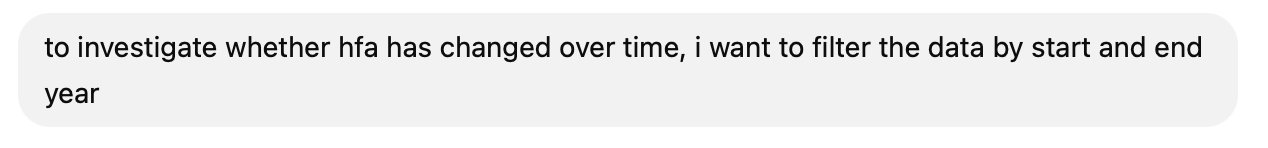